# 1D TV denoising: method comparison

This notebook checks all current 1D TV denoising methods in this repo:

1. Condat v1 direct 1D TV solver,
2. Condat v2 direct 1D TV solver,
3. ProxTV.jl reference solver,
4. TVDenoise.jl `tvd` sparse-ADMM solver,
5. weighted Kamilov one-pass shrinkage,
6. weighted Kamilov ISTA diagnostic experiment,
7. weighted Kamilov FISTA diagnostic experiment.

The main exact-reference comparison is Condat v1/v2, ProxTV.jl, and TVDenoise.jl. The Kamilov one-pass method is kept here because it is the method we are debugging; it does not match exact 1D TV. The former FPPA diagnostic is now named ISTA because it is exactly the proximal-gradient iteration from Kamilov's equations (18a)-(18b). FISTA adds Nesterov acceleration to the same proximal step.


In [1]:
import Pkg
Pkg.activate("docs")


## Weighted 1-norm proximal operator

For a scalar coefficient `z_j`, the weighted regularizer is

$$R(z) = \lambda \sum_j w_j |z_j|,$$

where `w_j` is either 0 or 1. The proximal problem separates over coefficients:

$$\operatorname{prox}_{R}(z_j) = \arg\min_u \frac{1}{2}(u-z_j)^2 + \lambda w_j |u|.$$

The solution is weighted soft-thresholding:

$$\operatorname{prox}_{R}(z_j) = \operatorname{sign}(z_j)\max(|z_j| - \lambda w_j, 0).$$

Therefore:

- if `w_j = 1`, shrink the coefficient toward zero;
- if `w_j = 0`, leave the coefficient unchanged.

For non-circular 1D TV, the wrap-around difference should not be penalized, so the wrap coefficient uses weight 0.

In [3]:
using Random, LinearAlgebra, Printf, Plots, BenchmarkTools
using ProxTV
using TVDenoise

include("src/tv1d_condat_v1.jl")
include("src/tv1d_condat_v2.jl")
include("src/tv1d_kamilov.jl")

function proxtv_1d(y, λ)
    h = NormTVp(λ, 1.0, length(y))
    x = similar(y, Float64)
    prox!(x, h, y, 1.0)
    return x
end


In [4]:
Random.seed!(7)

N = 200
xtrue = vcat(fill(0.0, 45), fill(2.0, 45), fill(-1.0, 55), fill(1.0, 55))
y = xtrue + 0.35 * randn(N)
λ = 1.2

rmse(x, y) = norm(x - y) / sqrt(length(x))
tv1_value(x) = sum(abs.(diff(x)))

In [5]:
x_condat_v1 = similar(y)
x_condat_v2 = similar(y)
x_kamilov_onepass = similar(y)

tv1d_condat_v1!(x_condat_v1, y, λ)
tv1d_condat_v2!(x_condat_v2, y, λ)
x_proxtv = proxtv_1d(y, λ)

# TVDenoise.jl sparse ADMM comparison.
# This is the 1D path of TVDenoise.tvd, using non-circular first-difference TV.
ρ_tvd = 5.0
x_tvd, hist_tvd = tvd(y, λ, ρ_tvd; maxit=10000, tol=1e-8, verbose=false)

tv1d_kamilov_onepass!(x_kamilov_onepass, y, λ)

# Diagnostic only: Kamilov equations (18a)-(18b) are an ISTA/proximal-gradient iteration.
# FISTA uses the same weighted Kamilov proximal step with Nesterov acceleration.
gammas = [0.0005, 0.0001, 0.00005, 0.0000317, 0.00001, 0.000005]
ista_maxiter = 200000
fista_maxiter = 20000
x_kamilov_ista = Dict(γ => tv1d_kamilov_ista(y, λ; γ=γ, maxiter=ista_maxiter) for γ in gammas)
x_kamilov_fista = Dict(γ => tv1d_kamilov_fista(y, λ; γ=γ, maxiter=fista_maxiter) for γ in gammas)

println("Condat v1 vs v2: ", norm(x_condat_v1 - x_condat_v2, Inf))
println("ProxTV.jl vs Condat: ", norm(x_proxtv - x_condat_v1, Inf))
println("TVDenoise.jl tvd vs Condat: ", norm(x_tvd - x_condat_v1, Inf),
        "  iterations=", hist_tvd.k, "  rho=", ρ_tvd)
println("One-pass weighted Kamilov vs Condat: ", norm(x_kamilov_onepass - x_condat_v1, Inf))
for γ in gammas
    xi = x_kamilov_ista[γ]
    xf = x_kamilov_fista[γ]
    println("ISTA  γ=", γ, ": inf error=", norm(xi - x_condat_v1, Inf), ", rmse=", rmse(xi, x_condat_v1))
    println("FISTA γ=", γ, ": inf error=", norm(xf - x_condat_v1, Inf), ", rmse=", rmse(xf, x_condat_v1))
end


Condat v1 vs v2: 1.3322676295501878e-15
ProxTV.jl vs Condat: 1.1102230246251565e-16
TVDenoise.jl tvd vs Condat: 1.0301186125216688e-6  iterations=343  rho=5.0
One-pass weighted Kamilov vs Condat: 0.7139299169902438
ISTA  γ=0.0005: inf error=0.014156661166093577, rmse=0.004743542359177703
FISTA γ=0.0005: inf error=0.014156638236021875, rmse=0.004743542359281781
ISTA  γ=0.0001: inf error=0.0029874666931149485, rmse=0.0008798717056907177
FISTA γ=0.0001: inf error=0.002992553282021339, rmse=0.0008799867259172871
ISTA  γ=5.0e-5: inf error=0.0015044059390760187, rmse=0.00042362790043540445
FISTA γ=5.0e-5: inf error=0.0014993787474730166, rmse=0.0004242922870643067
ISTA  γ=3.17e-5: inf error=0.0009563054807899263, rmse=0.00028965814392802546
FISTA γ=3.17e-5: inf error=0.0009798653088483808, rmse=0.0002746160335437789
ISTA  γ=1.0e-5: inf error=0.0192369028488808, rmse=0.008282234796998161
FISTA γ=1.0e-5: inf error=0.00047375938411675644, rmse=0.00012064807826436686
ISTA  γ=5.0e-6: inf error=0.

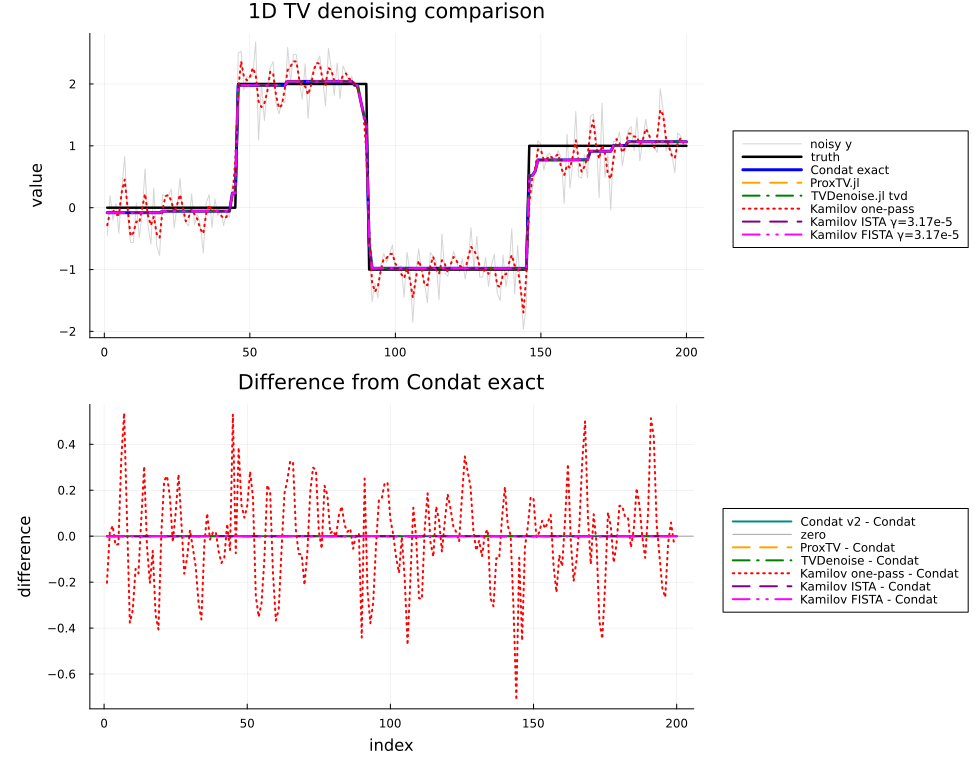

In [6]:
mkpath("figures")

γ_plot = 0.0000317
x_ista_plot = x_kamilov_ista[γ_plot]
x_fista_plot = x_kamilov_fista[γ_plot]

# Top panel: keep the signal readable. The exact/reference methods nearly overlap,
# so use distinct line styles and put the legend outside the plotting area.
p_signal = plot(
    y;
    label="noisy y",
    color=:gray70,
    alpha=0.55,
    linewidth=1,
    title="1D TV denoising comparison",
    ylabel="value",
    legend=:outerright,
    size=(920, 620),
)
plot!(p_signal, xtrue; label="truth", color=:black, linewidth=2.5)
plot!(p_signal, x_condat_v1; label="Condat exact", color=:blue, linewidth=3)
plot!(p_signal, x_proxtv; label="ProxTV.jl", color=:orange, linewidth=2, linestyle=:dash)
plot!(p_signal, x_tvd; label="TVDenoise.jl tvd", color=:green, linewidth=2, linestyle=:dashdot)
plot!(p_signal, x_kamilov_onepass; label="Kamilov one-pass", color=:red, linewidth=2, linestyle=:dot)
plot!(p_signal, x_ista_plot; label="Kamilov ISTA γ=$(γ_plot)", color=:purple, linewidth=2, linestyle=:dash)
plot!(p_signal, x_fista_plot; label="Kamilov FISTA γ=$(γ_plot)", color=:magenta, linewidth=2, linestyle=:dashdotdot)

# Bottom panel: compare differences from Condat directly.
# This makes overlapping exact methods and Kamilov errors visible without cluttering the signal.
p_error = plot(
    x_condat_v2 .- x_condat_v1;
    label="Condat v2 - Condat",
    color=:cyan4,
    linewidth=2,
    title="Difference from Condat exact",
    xlabel="index",
    ylabel="difference",
    legend=:outerright,
    size=(920, 620),
)
hline!(p_error, [0.0]; label="zero", color=:black, linewidth=1, linestyle=:solid, alpha=0.35)
plot!(p_error, x_proxtv .- x_condat_v1; label="ProxTV - Condat", color=:orange, linewidth=2, linestyle=:dash)
plot!(p_error, x_tvd .- x_condat_v1; label="TVDenoise - Condat", color=:green, linewidth=2, linestyle=:dashdot)
plot!(p_error, x_kamilov_onepass .- x_condat_v1; label="Kamilov one-pass - Condat", color=:red, linewidth=2, linestyle=:dot)
plot!(p_error, x_ista_plot .- x_condat_v1; label="Kamilov ISTA - Condat", color=:purple, linewidth=2, linestyle=:dash)
plot!(p_error, x_fista_plot .- x_condat_v1; label="Kamilov FISTA - Condat", color=:magenta, linewidth=2, linestyle=:dashdotdot)

p = plot(p_signal, p_error; layout=(2, 1), size=(980, 760), left_margin=6Plots.mm)
savefig(p, "figures/main1d_signal.png")
p


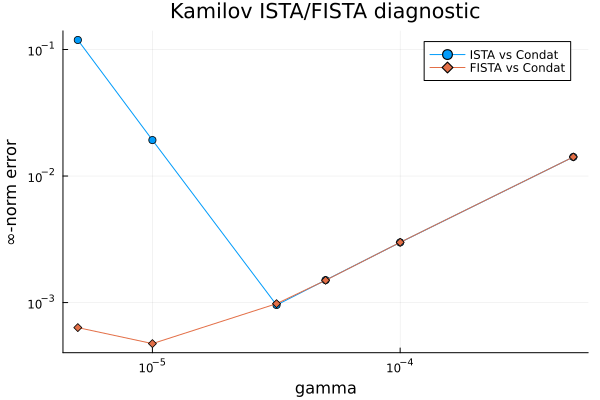

In [7]:
errs_ista = [norm(x_kamilov_ista[γ] - x_condat_v1, Inf) for γ in gammas]
errs_fista = [norm(x_kamilov_fista[γ] - x_condat_v1, Inf) for γ in gammas]
p2 = plot(gammas, errs_ista, xscale=:log10, yscale=:log10, marker=:circle,
          label="ISTA vs Condat", title="Kamilov ISTA/FISTA diagnostic",
          xlabel="gamma", ylabel="∞-norm error")
plot!(p2, gammas, errs_fista; marker=:diamond, label="FISTA vs Condat")
savefig(p2, "figures/main1d_gamma_error.png")
p2


## ISTA/FISTA benchmark

This benchmark measures implementation cost for a fixed number of iterations using preallocated workspaces. It is not a convergence-to-tolerance benchmark; FISTA can need fewer iterations for similar accuracy, as shown above.


In [9]:
bench_iters = 10_000
bench_γ = 1.0e-5

x_ista_b = similar(y)
a_ista_b = similar(y)
d_ista_b = similar(y)
z_ista_b = similar(y)
xprev_ista_b = similar(y)

x_fista_b = similar(y)
a_fista_b = similar(y)
d_fista_b = similar(y)
z_fista_b = similar(y)
xprev_fista_b = similar(y)
q_fista_b = similar(y)
qprev_fista_b = similar(y)

bench_ista = @benchmark tv1d_kamilov_ista!(
    $x_ista_b, $y, $λ, $a_ista_b, $d_ista_b, $z_ista_b, $xprev_ista_b;
    γ=$bench_γ, maxiter=$bench_iters,
)
bench_fista = @benchmark tv1d_kamilov_fista!(
    $x_fista_b, $y, $λ, $a_fista_b, $d_fista_b, $z_fista_b, $xprev_fista_b,
    $q_fista_b, $qprev_fista_b;
    γ=$bench_γ, maxiter=$bench_iters,
)

function bench_row(name, b)
    t_ms = median(b).time / 1e6
    mem = median(b).memory
    allocs = median(b).allocs
    @printf("%-8s  median time = %.3f ms, memory = %d bytes, allocations = %d
", name, t_ms, mem, allocs)
    return (method=name, median_ms=t_ms, memory_bytes=mem, allocations=allocs)
end

bench_results = [
    bench_row("ISTA", bench_ista),
    bench_row("FISTA", bench_fista),
]


ISTA      median time = 2.728 ms, memory = 0 bytes, allocations = 0
FISTA     median time = 3.338 ms, memory = 0 bytes, allocations = 0
